In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

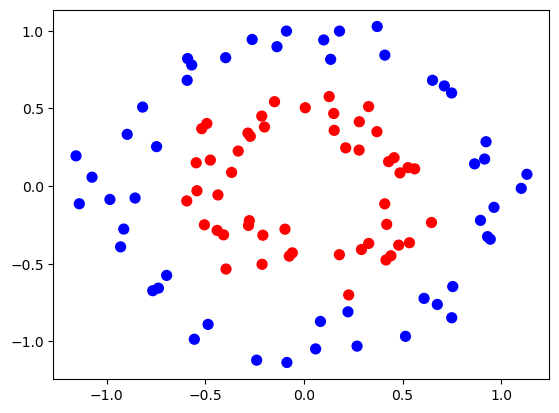

In [23]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

x, y = make_circles(n_samples=100, factor=0.5, noise=0.1)
plt.scatter(x[:,0], x[:,1], c=y, s=50, cmap="bwr")
plt.show()


In [24]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.20)

In [25]:
classifier=SVC(kernel="linear")
classifier.fit(x_train , y_train.ravel())
y_pred= classifier.predict(x_test)

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.35

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

zero_one_colourmap = ListedColormap(("blue", "red"))

def plot_decision_boundary(x, y, clf):
    x_set, y_set = x, y

    # Create a grid of points
    x1, x2 = np.meshgrid(
        np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
        np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
    )

    # Predict on the grid
    grid_points = np.c_[x1.ravel(), x2.ravel()]
    predictions = clf.predict(grid_points).reshape(x1.shape)

    # Plot the decision boundary
    plt.contourf(x1, x2, predictions, alpha=0.75, cmap=zero_one_colourmap)
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())

    # Plot the data points
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            x_set[y_set == j, 0],
            x_set[y_set == j, 1],
            c=[zero_one_colourmap(i)],
            label=j
        )

    plt.title("SVM Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


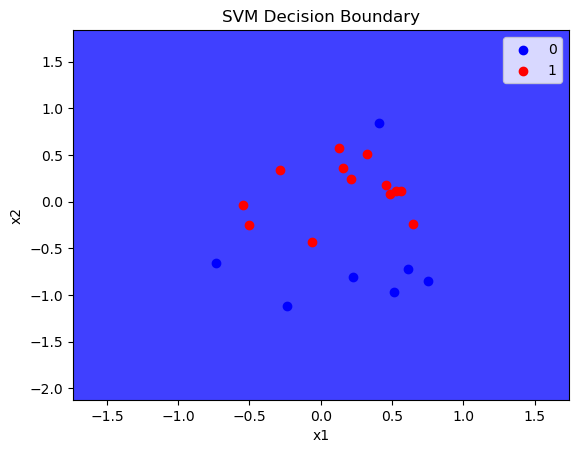

In [38]:
plot_decision_boundary(x_test,y_test,classifier)

#### The provided image shows a case of underfitting. The SVM model is unable to find a suitable decision boundary to separate the blue and red data points. As a result, it classifies the entire feature space as a single class (in this case, class '0'), leading to a completely blue plot with no visible boundary.

In [45]:
def plot_3d_plot(x,y):
    r=np.exp(-(x**2).sum(1))# z-axis
    ax=plt.subplot(projection="3d")
    ax.scatter3D(x[:,0],x[:,1],r,c=y,s=100,cmap="bwr")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    return ax

<Axes3D: xlabel='x1', ylabel='x2', zlabel='y'>

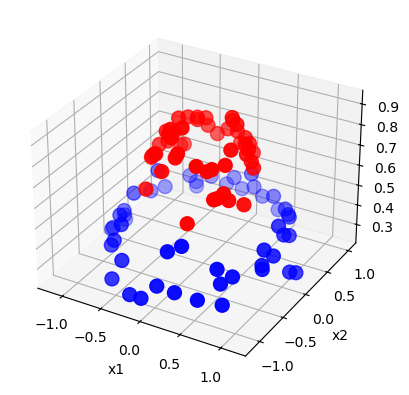

In [46]:
plot_3d_plot(x,y)

In [ ]:
-